In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
path=r"C:\Users\piyus\Desktop\Desk Top\02-04-2026 Mess to sort out\Project 02 European Bank\European_Bank.csv"
df=pd.read_csv(path)
print("Loaded Dataset sucessfully!")

Loaded Dataset sucessfully!


In [3]:
df

,Year,Customer Id,Surname,Credit Score,Geography,Gender,Age,Tenure,Balance,Number Of Products,Has Credit Card,Is Active Member,Estimated Salary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2025,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,2025,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,2025,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,2025,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


# 1. Gender-based churn differences

In [4]:
class glob:
    def __init__(self):
        self.gen_exit()
        self.region()

    def gen_exit(self):
        self.male_left=df[(df["Gender"]=="Male")&(df["Exited"]==1)].shape[0]
        self.male_stayed=df[(df["Gender"]=="Male")&(df["Exited"]==0)].shape[0]
       
        self.female_left=df[(df["Gender"]=="Female")&(df["Exited"]==1)].shape[0]
        self.female_stayed=df[(df["Gender"]=="Female")&(df["Exited"]==0)].shape[0]
        
    def region(self):
        self.sp=df[df["Geography"]=="Spain"]
        self.fr=df[df["Geography"]=="France"]
        self.ge=df[df["Geography"]=="Germany"]
        
        

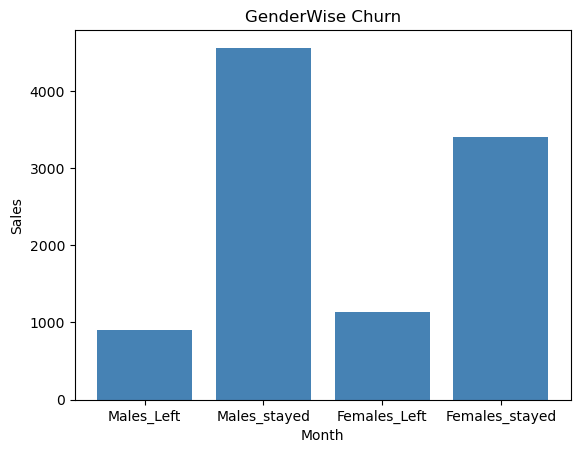

In [5]:
lr=glob()

categories = ['Males_Left', 'Males_stayed','Females_Left', 'Females_stayed']
values     = [lr.male_left, lr.male_stayed, lr.female_left, lr.female_stayed]
explode = (0, 0.1, 0, 0)

plt.bar(categories, values, color='steelblue')
plt.title('GenderWise Churn')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()



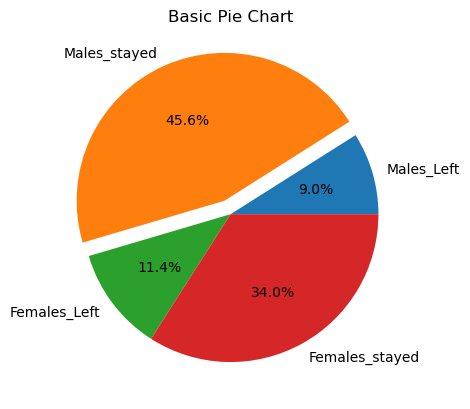

In [6]:
import matplotlib.pyplot as plt

     # must sum to 100

plt.pie(values, labels=categories,autopct='%1.1f%%', explode=explode)
plt.title('Basic Pie Chart')
plt.show()

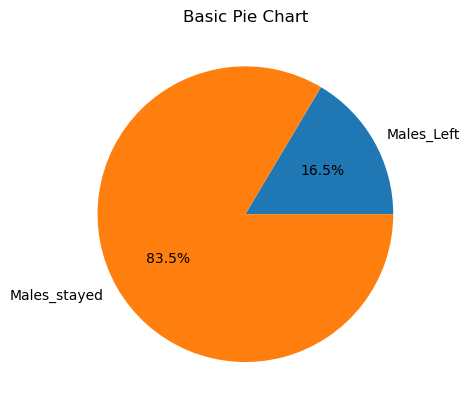

In [7]:
categories_m = ['Males_Left', 'Males_stayed']
values_m     = [lr.male_left, lr.male_stayed]

categories_f = ['Females_Left', 'Females_stayed']
values_f     = [ lr.female_left, lr.female_stayed]

plt.pie(values_m, labels=categories_m,autopct='%1.1f%%')
plt.title('Basic Pie Chart')
plt.show()

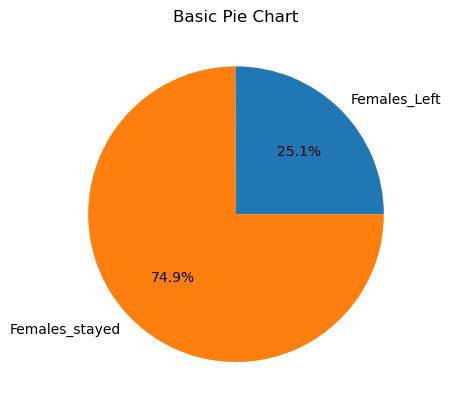

In [8]:


plt.pie(values_f, labels=categories_f,autopct='%1.1f%%')
plt.title('Basic Pie Chart')
plt.show()

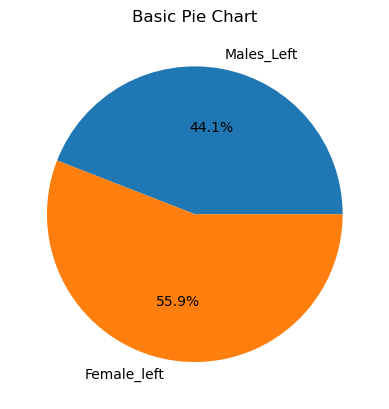

In [9]:
categories_churn = ['Males_Left', 'Female_left']
values_churn     = [lr.male_left, lr.female_left]

plt.pie(values_churn, labels=categories_churn,autopct='%1.1f%%')
plt.title('Basic Pie Chart')
plt.show()

### Women have a higher Churn then men

The value of Customers Left who were Male within France's area is 350

## 2. Geography-age interaction analysis

In [39]:
# country_1=input()
nm=df[df["Geography"]=="Germany"]

below_30_Filter = nm[(nm["Age"]<30)]
above_30_to_45_Filter = nm[(nm["Age"]>30)&(nm["Age"]<45)]
above_46_to_60_Filter = nm[(nm["Age"]>46)&(nm["Age"]<60)]
above_60_Filter = nm[(nm["Age"]>60)]

Ret_below_30 = below_30_Filter[below_30_Filter["Exited"]==1]
Churn_below_30 = below_30_Filter[below_30_Filter["Exited"]==0]

Ret_above_30_to_45 = above_30_to_45_Filter[above_30_to_45_Filter["Exited"]==1]
Churn_above_30_to_45 = above_30_to_45_Filter[above_30_to_45_Filter["Exited"]==0]

Ret_above_46_to_60 = above_46_to_60_Filter[above_46_to_60_Filter["Exited"]==1]
Churn_above_46_to_60 = above_46_to_60_Filter[above_46_to_60_Filter["Exited"]==0]

Ret_above_60 = above_60_Filter[above_60_Filter["Exited"]==1]
Churn_above_60 = above_60_Filter[above_60_Filter["Exited"]==0]



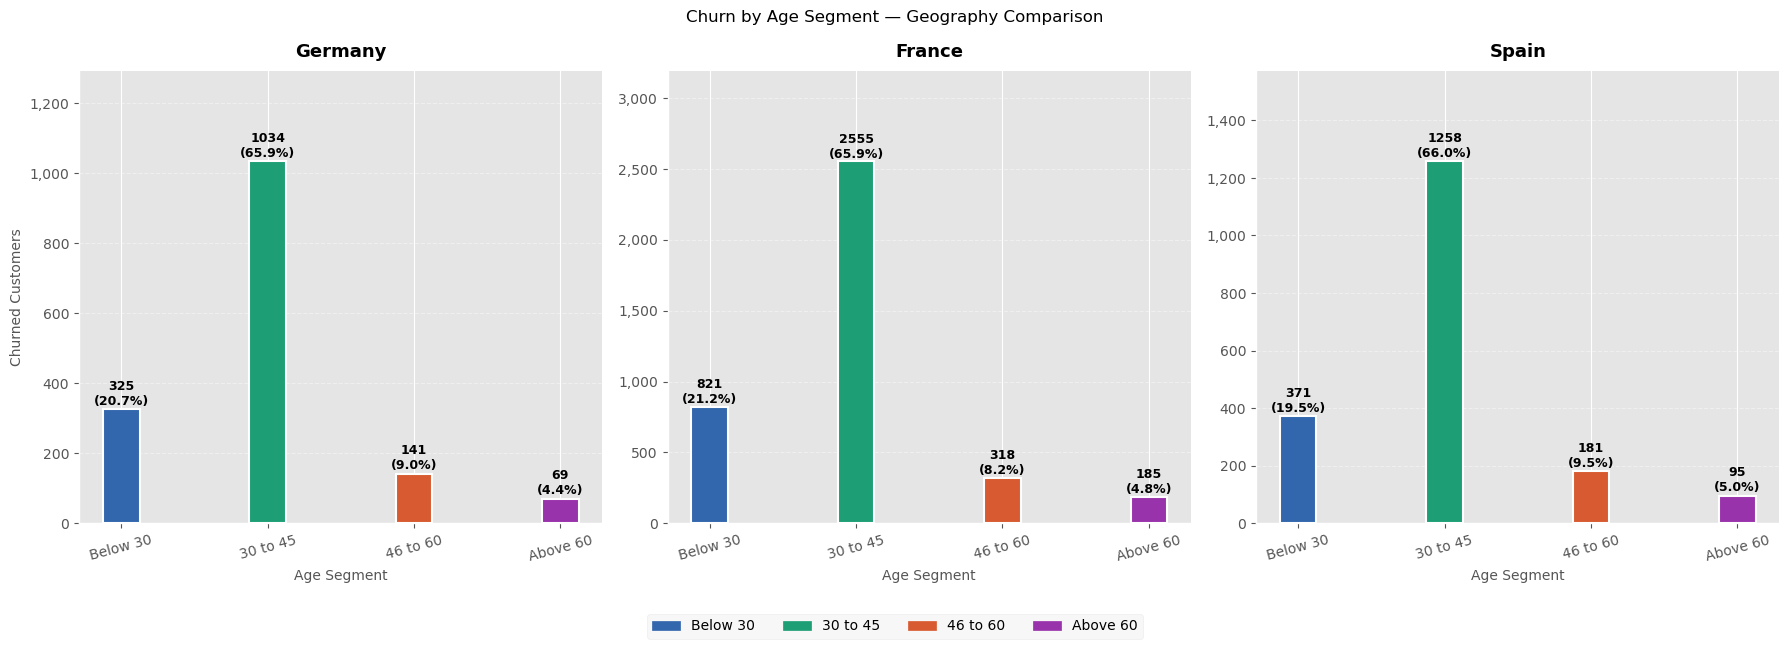

In [38]:

import matplotlib.patches as mpatches

def get_churn_counts(df, country):
    nm = df[df["Geography"] == country]
    groups = {
        "Below 30":  nm[nm["Age"] < 30],
        "30 to 45":  nm[(nm["Age"] > 30) & (nm["Age"] < 45)],
        "46 to 60":  nm[(nm["Age"] > 46) & (nm["Age"] < 60)],
        "Above 60":  nm[nm["Age"] > 60]
    }
    return [g[g["Exited"] == 0].shape[0] for g in groups.values()]

countries  = ["Germany", "France", "Spain"]
colors     = ['#3266ad', '#1d9e75', '#d85a30', '#9933ab']
Age_Segment = ["Below 30", "30 to 45", "46 to 60", "Above 60"]
flag        = {"Germany": "🇩🇪", "France": "🇫🇷", "Spain": "🇪🇸"}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Churn by Age Segment — Geography Comparison")

for ax, country in zip(axes, countries):
    churn = get_churn_counts(df, country)
    total = sum(churn)
    bars  = ax.bar(Age_Segment, churn, color=colors,
                   edgecolor='white', linewidth=1.5, width=0.25)

    for bar, val in zip(bars, churn):
        pct = val / total * 100
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 5,
                f'{val}\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(f'{country}', fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Age Segment', fontsize=10)
    ax.set_ylabel('Churned Customers' if country == "Germany" else '', fontsize=10)
    ax.set_ylim(0, max(churn) * 1.25)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', rotation=15)

patches = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, Age_Segment)]
fig.legend(handles=patches, loc='lower center', ncol=4,
           fontsize=10, framealpha=0.3, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.show()

## 3. Financial stability vs churn comparison

In [42]:
from sklearn.preprocessing import MinMaxScaler

cols_to_scale = ['Credit Score', 'Balance', 'Estimated Salary', 'Tenure', 'Number Of Products']
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

In [44]:
weights = {
    'Credit Score':     0.30,
    'Balance':         0.25,
    'Estimated Salary': 0.20,
    'Tenure':          0.15,
    'Number Of Products':   0.05,
    'Is Active Member':  0.03,
    'Has Credit Card':       0.02
}

df['FSS'] = sum(df_scaled[col] * w for col, w in weights.items())
df['FSS'] = (df['FSS'] * 100).round(2)  # scale to 0–100

In [45]:
df['Stability_Tier'] = pd.cut(df['FSS'],
    bins=[0, 30, 50, 70, 100],
    labels=['At Risk', 'Moderate', 'Stable', 'High Stability'])

In [47]:
df

,Year,Customer Id,Surname,Credit Score,Geography,Gender,Age,Tenure,Balance,Number Of Products,Has Credit Card,Is Active Member,Estimated Salary,Exited,FSS,Stability_Tier
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,34.27,Moderate
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,39.58,Moderate
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,53.76,Stable
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,33.49,Moderate
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,58.41,Stable
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2025,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,46.05,Moderate
9996,2025,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,45.85,Moderate
9997,2025,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,39.25,Moderate
9998,2025,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,50.26,Stable


<BarContainer object of 4 artists>

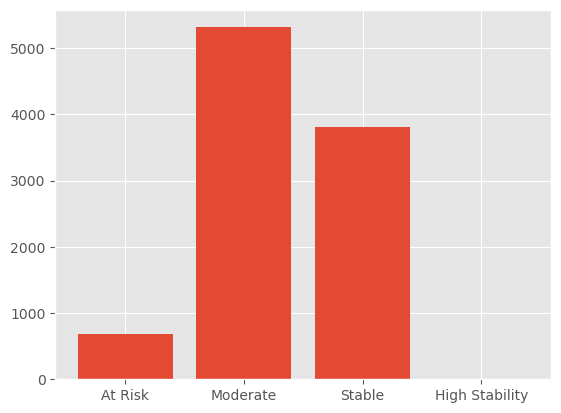

In [50]:
fss=[df[df["Stability_Tier"]=="At Risk"].shape[0],
df[df["Stability_Tier"]=="Moderate"].shape[0],
df[df["Stability_Tier"]=="Stable"].shape[0],
df[df["Stability_Tier"]=="High Stabillity"].shape[0]]
C=['At Risk', 'Moderate', 'Stable', 'High Stability']

plt.bar(C,fss)

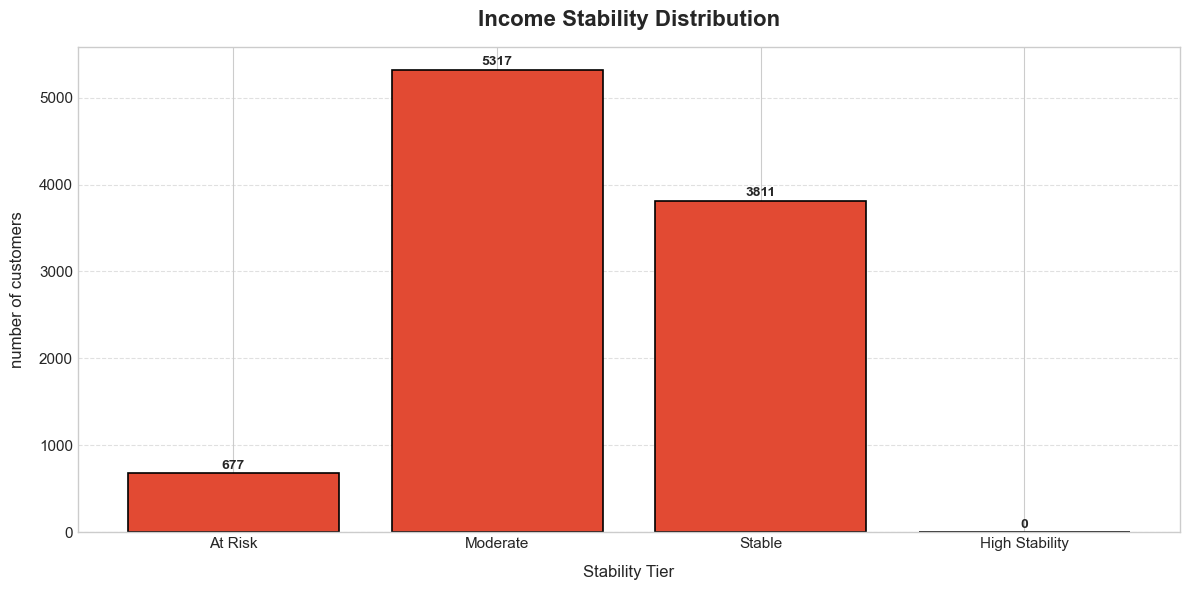

In [53]:
import matplotlib.pyplot as plt

# Data
fss = [
    df[(df["Stability_Tier"] == "At Risk")].shape[0],
    df[(df["Stability_Tier"] == "Moderate")].shape[0],
    df[(df["Stability_Tier"] == "Stable")].shape[0],
    df[(df["Stability_Tier"] == "High Stabillity")].shape[0]
]

C = ['At Risk', 'Moderate', 'Stable', 'High Stability']

# Style
plt.style.use("seaborn-v0_8-whitegrid")

# Figure
plt.figure(figsize=(12, 6))

# Bar Plot
bars = plt.bar(C, fss, edgecolor='black', linewidth=1.2)

# Title & Labels
plt.title("Income Stability Distribution", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Stability Tier", fontsize=12, labelpad=10)
plt.ylabel("number of customers", fontsize=12, labelpad=10)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Tick Styling
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Value Labels on Bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + max(fss)*0.01,
        f'{int(height)}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# Tight Layout
plt.tight_layout()

# Show
plt.show()

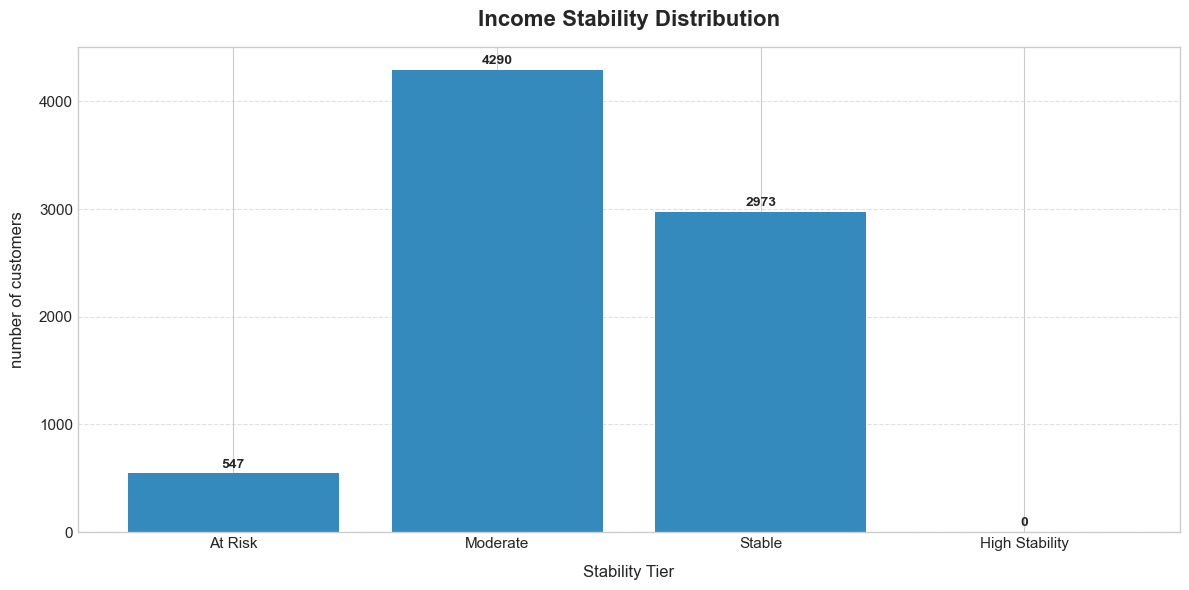

In [56]:
import matplotlib.pyplot as plt

# Data
Churn = [
    df[(df["Stability_Tier"] == "At Risk")&(df["Exited"] == 1)].shape[0],
    df[(df["Stability_Tier"] == "Moderate")&(df["Exited"] == 1)].shape[0],
    df[(df["Stability_Tier"] == "Stable")&(df["Exited"] == 1)].shape[0],
    df[(df["Stability_Tier"] == "High Stabillity")&(df["Exited"] == 1)].shape[0]
]

Ret = [
    df[(df["Stability_Tier"] == "At Risk")&(df["Exited"] == 0)].shape[0],
    df[(df["Stability_Tier"] == "Moderate")&(df["Exited"] == 0)].shape[0],
    df[(df["Stability_Tier"] == "Stable")&(df["Exited"] == 0)].shape[0],
    df[(df["Stability_Tier"] == "High Stabillity")&(df["Exited"] == 0)].shape[0]
]

C = ['At Risk', 'Moderate', 'Stable', 'High Stability']

# Style
plt.style.use("seaborn-v0_8-whitegrid")

# Figure
plt.figure(figsize=(12, 6))

# Bar Plot
bars = plt.bar(C, Churn)

# Title & Labels
plt.title("Income Stability Distribution", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Stability Tier", fontsize=12, labelpad=10)
plt.ylabel("number of customers", fontsize=12, labelpad=10)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Tick Styling
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Value Labels on Bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + max(fss)*0.01,
        f'{int(height)}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# Tight Layout
plt.tight_layout()

# Show
plt.show()

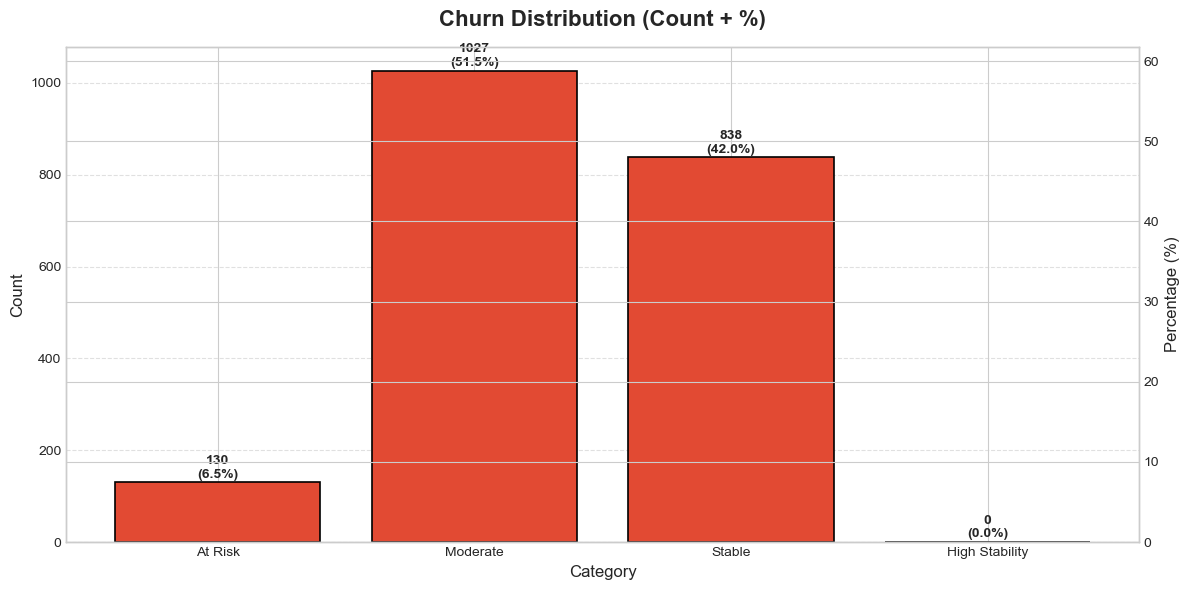

In [67]:
import matplotlib.pyplot as plt
import numpy as np

# Data
total = sum(Churn)
percentages = [(x / total) * 100 for x in Churn]

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar plot (Counts)
bars = ax1.bar(C, Churn, edgecolor='black', linewidth=1.2)

# Left Y-axis (Counts)
ax1.set_ylabel("Count", fontsize=12)
ax1.set_xlabel("Category", fontsize=12)
ax1.set_title("Churn Distribution (Count + %)", fontsize=16, fontweight='bold', pad=15)
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Right Y-axis (Percentage)
ax2 = ax1.twinx()
ax2.set_ylabel("Percentage (%)", fontsize=12)
ax2.set_ylim(0, max(percentages) * 1.2)

# Labels (Count + % on bars)
for bar, count, pct in zip(bars, Churn, percentages):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + max(Churn)*0.01,
        f"{count}\n({pct:.1f}%)",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

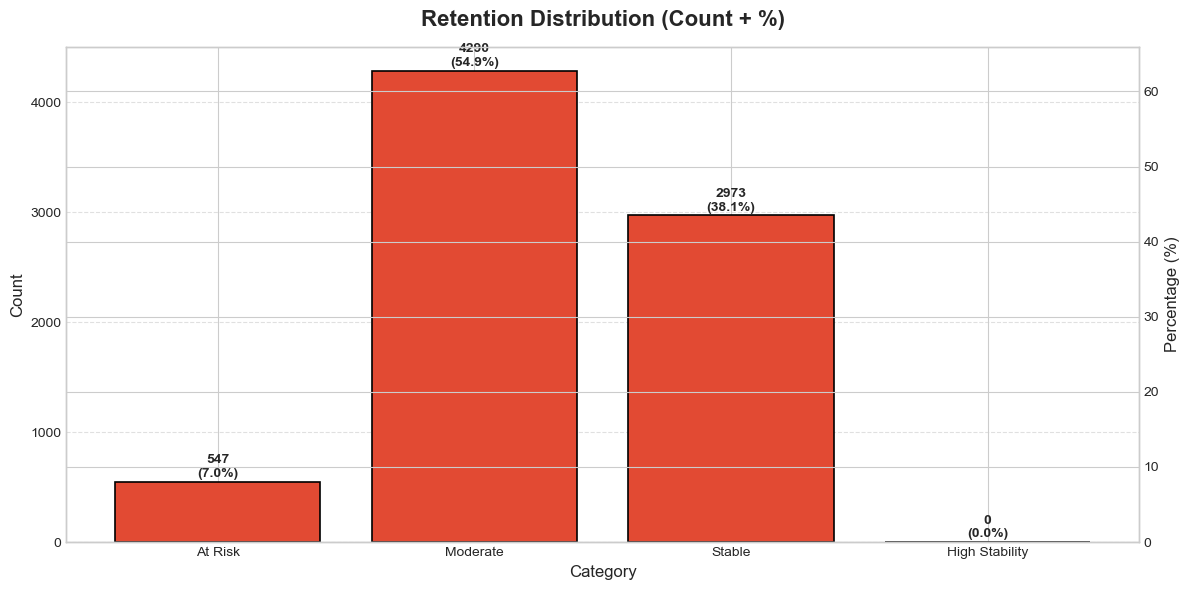

In [68]:
import matplotlib.pyplot as plt

# Convert to %
total = sum(Ret)
percentages = [(x / total) * 100 for x in Ret]

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bars (Counts)
bars = ax1.bar(C, Ret, edgecolor='black', linewidth=1.2)

# Labels & Title
ax1.set_title("Retention Distribution (Count + %)", fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel("Category", fontsize=12)
ax1.set_ylabel("Count", fontsize=12)

# Grid
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Secondary axis for %
ax2 = ax1.twinx()
ax2.set_ylabel("Percentage (%)", fontsize=12)
ax2.set_ylim(0, max(percentages) * 1.2)

# Annotations (Count + %)
for bar, count, pct in zip(bars, Ret, percentages):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + max(Ret)*0.01,
        f"{count}\n({pct:.1f}%)",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

# 3. High-Value Customer Churn Analysis

In [1]:
# Identifying 